In [15]:
import numpy as np
import matplotlib.pyplot as plt

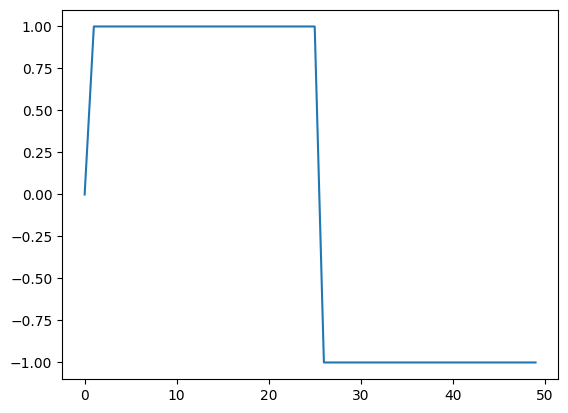

In [ ]:
def step_function(frequency: int, length: int, sample_rate: int) -> np.ndarray:
    t = np.arange(0, length/sample_rate, 1/sample_rate)
    return np.sign(np.sin(2 * np.pi * frequency * t))


plt.plot(step_function(1, 50, 50))

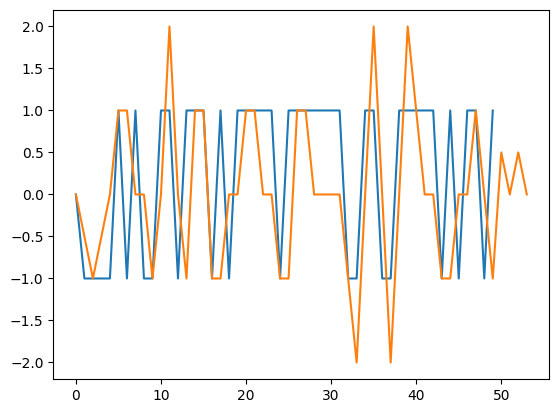

In [ ]:
def convolve_1D(arr1: np.ndarray, arr2: np.ndarray) -> np.ndarray:
    arrays = [arr1, arr2]
    smallest_array = np.argmin([arr1.shape[0], arr2.shape[0]])
    largest_array = np.argmax([arr1.shape[0], arr2.shape[0]])
    kernel = arrays[smallest_array]
    singal = arrays[largest_array]

    convolution_length = singal.shape[0] + kernel.shape[0] - 1
    convolution = np.zeros(convolution_length)

    # Treating arr1 as static and arr2 as the "window"
    for i in range(singal.shape[0]):
        window_size = min(i+1, kernel.shape[0])
        sub2 = kernel[:window_size][::-1]

        sub1 = singal[max(0, i-window_size+1):i+1]

        convolution[i] = np.dot(sub1, sub2)

    for i in range(convolution_length - singal.shape[0]):
        window_size = kernel.shape[0] - min(i+1, kernel.shape[0])
        sub2 = kernel[-window_size:]
        sub1 = singal[-window_size:]
        convolution[singal.shape[0] + i] = np.dot(sub1, sub2)

    return convolution


arr1 = step_function(2, 50, 50)
arr2 = np.array([0.5, 0.5, -0.5, -0.5, 0])

plt.plot(arr1)
plt.plot(convolve_1D(arr1, arr2))

In [56]:
arr1.shape, convolve_1D(arr1, arr2).shape

((50,), (52,))